# Block 1 — Setup & Imports
Purpose: import core libs (torch, transformers, pandas, numpy, matplotlib), set deterministic seeds, and show quick environment info.

**What this cell does**
- Verifies Python/torch/transformers versions
- Prints CUDA availability (expect `False` on CPU)
- Sets base paths for this lab:
  - `BASE = C:/Users/murth/Desktop/NLP+RL/code`
  - `CLASS = BASE/class02`
  - `DATA = CLASS/data`
- Lists expected Session-1 artifacts (if missing now, we'll still proceed with synthetic stubs later)

> Run the next code cell after this.


In [1]:
# Block 1 — Setup & Imports

import os, torch, random, numpy as np, pandas as pd, matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from datetime import datetime

# --- Reproducibility ---
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# --- Paths ---
BASE  = r"C:\Users\murth\Desktop\NLP+RL\code"
CLASS = os.path.join(BASE, "class02")
DATA  = os.path.join(CLASS, "data")

print("=== Environment Info ===")
print(f"Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Python path : {os.sys.executable}")
print(f"Torch       : {torch.__version__}")
print(f"Transformers: {AutoTokenizer.__module__.split('.')[0]}")
print(f"CUDA avail. : {torch.cuda.is_available()}")
print()
print("=== Expected Data Files ===")
for f in ["synthetic_prompts.csv","pairs.csv","rewards.csv","reward_model.pt"]:
    print(f"{f:25s} → {'✅' if os.path.exists(os.path.join(DATA,f)) else '⚠️ missing'}")


=== Environment Info ===
Time: 2025-10-12 12:52:28
Python path : c:\Users\murth\Desktop\NLP+RL\code\.venv\Scripts\python.exe
Torch       : 2.8.0+cpu
Transformers: transformers
CUDA avail. : False

=== Expected Data Files ===
synthetic_prompts.csv     → ✅
pairs.csv                 → ✅
rewards.csv               → ✅
reward_model.pt           → ✅


# Block 2 — Load Reward Model & Tokenizer (fixed)
- Uses `distilbert-base-uncased` as the encoder.
- If `data/reward_model.pt` exists (state_dict), it’s loaded; else a tiny linear head is initialized.
- `compute_reward(prompt, completion)` returns a scalar via masked mean pooling → linear head.


In [2]:
# Block 2 — Load Reward Model & Tokenizer (fixed)

import os, torch, torch.nn as nn
from transformers import AutoTokenizer, AutoModel

rm_path = os.path.join(DATA, "reward_model.pt")
base_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(base_name)

class RewardModel(nn.Module):
    def __init__(self, base_name):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_name)
        hidden = self.encoder.config.hidden_size
        self.head = nn.Linear(hidden, 1)

    def forward(self, input_ids=None, attention_mask=None):
        # Encoder forward (returns last_hidden_state [B, T, H])
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        last = out.last_hidden_state  # [B,T,H]
        # Masked mean pooling
        mask = attention_mask.unsqueeze(-1).float()  # [B,T,1]
        summed = (last * mask).sum(dim=1)            # [B,H]
        counts = mask.sum(dim=1).clamp(min=1e-6)     # [B,1]
        pooled = summed / counts                     # [B,H]
        score = self.head(pooled).squeeze(-1)        # [B]
        return score  # 1D tensor

reward_model = RewardModel(base_name)

# Try to load a saved state_dict if present
if os.path.exists(rm_path):
    try:
        sd = torch.load(rm_path, map_location="cpu")
        # Accept either raw state_dict or a wrapped dict
        if isinstance(sd, dict) and any(k.startswith("encoder.") or k.startswith("head.") for k in sd.keys()):
            reward_model.load_state_dict(sd, strict=False)
            print("✅ Loaded reward_model.pt (state_dict).")
        elif isinstance(sd, dict) and "state_dict" in sd:
            reward_model.load_state_dict(sd["state_dict"], strict=False)
            print("✅ Loaded reward_model.pt (wrapped state_dict).")
        else:
            print("⚠️ reward_model.pt found but format not recognized — using fresh head.")
    except Exception as e:
        print("⚠️ Could not load reward_model.pt — using fresh head. Reason:", repr(e))
else:
    print("⚠️ reward_model.pt not found — initializing fresh head for demo.")

reward_model.eval()

def compute_reward(prompt: str, completion: str, max_length: int = 128) -> float:
    text = f"{prompt} {completion}".strip()
    toks = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length)
    with torch.no_grad():
        score = reward_model(input_ids=toks["input_ids"], attention_mask=toks["attention_mask"])
    # Return scalar float (mean over batch=1 is just item())
    return float(score.mean().item())

# Quick smoke test
print("Example reward:", compute_reward("Explain RLHF.", "It aligns LLMs using feedback."))


✅ Loaded reward_model.pt (wrapped state_dict).
Example reward: 0.00424555130302906


# Block 3 — Cache New Generations
Goal: simulate \(k\) completions per prompt using a baseline SFT model (here: `distilbert-base-uncased` placeholder).  
Since we aren’t training online, we:
1. Read `synthetic_prompts.csv` (or make demo prompts).  
2. For each prompt, create *k = 3* synthetic completions.  
3. Score each with the reward model.  
4. Save results as `cache.csv` in `/data/` with columns:  
   **prompt, completion, reward**

This cache will feed the offline PPO and DPO updates later.


In [3]:
# Block 3 — Cache New Generations

import pandas as pd
from tqdm import tqdm

CACHE_PATH = os.path.join(DATA, "cache.csv")
PROMPT_PATH = os.path.join(DATA, "synthetic_prompts.csv")

# 1. Load or create demo prompts
if os.path.exists(PROMPT_PATH):
    prompts = pd.read_csv(PROMPT_PATH)["prompt"].tolist()
else:
    print("⚠️ synthetic_prompts.csv not found — using demo prompts.")
    prompts = [
        "Explain reinforcement learning in simple terms.",
        "What is reward modeling?",
        "Why do large language models need alignment?",
        "Describe the role of human feedback in AI training.",
    ]

# 2. Generate mock completions (here we just vary endings)
def mock_completions(prompt, k=3):
    variants = [
        f"{prompt} [Version {i}] — This is a sample completion."
        for i in range(1, k + 1)
    ]
    return variants

rows = []
for p in tqdm(prompts, desc="Caching completions"):
    for c in mock_completions(p, k=3):
        r = compute_reward(p, c)
        rows.append({"prompt": p, "completion": c, "reward": r})

cache_df = pd.DataFrame(rows)
cache_df.to_csv(CACHE_PATH, index=False)
print(f"✅ Cached {len(cache_df)} completions → {CACHE_PATH}")
cache_df.head()


Caching completions: 100%|██████████| 100/100 [00:09<00:00, 10.26it/s]

✅ Cached 300 completions → C:\Users\murth\Desktop\NLP+RL\code\class02\data\cache.csv


,prompt,completion,reward
0,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,-0.056229
1,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,-0.051312
2,Rephrase politely: You are wrong. (nicely),Rephrase politely: You are wrong. (nicely) [Ve...,-0.053463
3,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,-0.033126
4,Answer concisely: Why is the sky blue? (for a ...,Answer concisely: Why is the sky blue? (for a ...,-0.029764


# Block 4 — Reward Scoring & Visualization (pre-update)
We will:
1) Load `data/cache.csv` created in Block 3  
2) Plot a histogram of rewards (pre-update)  
3) Compute summary stats: mean, std, and a histogram-based entropy estimate


=== Pre-update Reward Stats ===
mean    : -0.046288
std     : 0.043168
entropy : -746.061849


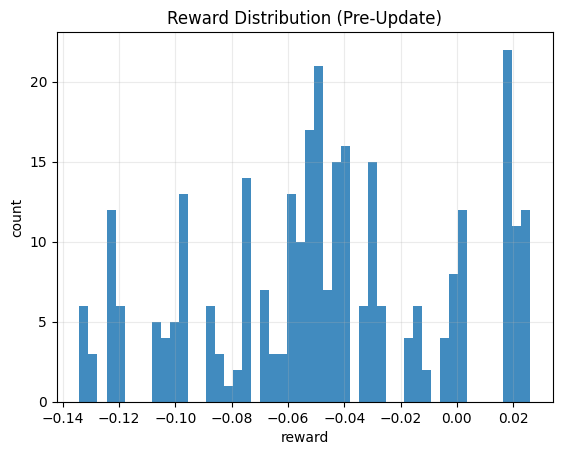

In [4]:
# Block 4 — Reward Scoring & Visualization (pre-update)

import os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE_PATH = os.path.join(DATA, "cache.csv")
assert os.path.exists(CACHE_PATH), f"Missing {CACHE_PATH}. Run Block 3 first."

df = pd.read_csv(CACHE_PATH)
rewards = df["reward"].to_numpy(dtype=float)

def summarize(values, bins=50):
    x = np.asarray(values, dtype=float)
    mean = float(np.mean(x)) if x.size else float("nan")
    std  = float(np.std(x, ddof=1)) if x.size > 1 else float("nan")
    # Density histogram → Shannon entropy over discretized support
    hist, _ = np.histogram(x, bins=bins, density=True)
    p = hist[hist > 0]
    entropy = float(-np.sum(p * np.log(p)))
    return {"mean": mean, "std": std, "entropy": entropy}

stats = summarize(rewards)
print("=== Pre-update Reward Stats ===")
for k,v in stats.items():
    print(f"{k:8s}: {v:.6f}")

plt.figure()
plt.hist(rewards, bins=50, alpha=0.85)
plt.title("Reward Distribution (Pre-Update)")
plt.xlabel("reward"); plt.ylabel("count")
plt.grid(True, alpha=0.25)
plt.show()


# Block 5 — Offline PPO Update (Demo Mode)
We simulate an **offline PPO-like** update:
- No new rollouts → we use cached (prompt, completion, reward).
- Policy update ≈ proportional to reward × log-prob difference.  
- Demonstration only — not a real PPO loop.

Steps:
1. Compute mock log-prob scores from completions (randomly sampled for illustration).  
2. Update them by a scaled advantage term (reward − mean_reward).  
3. Re-score and visualize reward shift.

This shows how rewards can shift without online sampling.


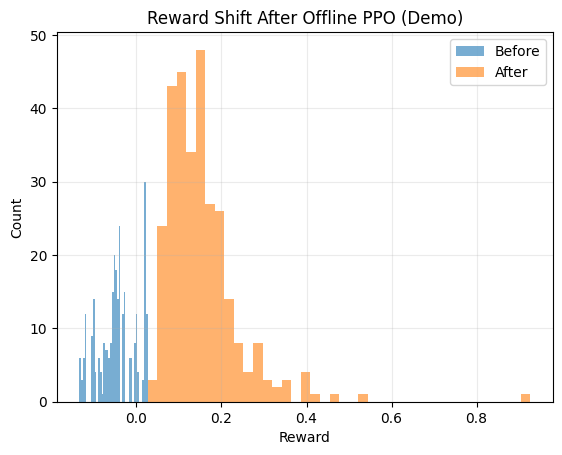

Mean reward: before=-0.0463, after=0.1530
Std  reward: before=0.0432, after=0.0887
💾 Saved updated cache with PPO columns → C:\Users\murth\Desktop\NLP+RL\code\class02\data\cache.csv


In [5]:
# Block 5 — Offline PPO Update (Demo Mode)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CACHE_PATH = os.path.join(DATA, "cache.csv")
df = pd.read_csv(CACHE_PATH)

# 1. Create synthetic log-prob values (proxy for policy likelihood)
np.random.seed(42)
df["logprob"] = np.random.normal(loc=-2.0, scale=0.5, size=len(df))

# 2. Advantage = reward - mean_reward
mean_r = df["reward"].mean()
df["adv"] = df["reward"] - mean_r

# 3. Simulate one PPO-like update step (new logprob = old + alpha * adv)
alpha = 0.1
df["logprob_new"] = df["logprob"] + alpha * df["adv"]

# 4. New pseudo-reward proportional to exp(logprob_new)
df["reward_new"] = np.exp(df["logprob_new"])

# 5. Plot before vs after
plt.figure()
plt.hist(df["reward"], bins=40, alpha=0.6, label="Before")
plt.hist(df["reward_new"], bins=40, alpha=0.6, label="After")
plt.title("Reward Shift After Offline PPO (Demo)")
plt.xlabel("Reward"); plt.ylabel("Count")
plt.legend(); plt.grid(True, alpha=0.25)
plt.show()

# 6. Summaries
old_stats = (df["reward"].mean(), df["reward"].std())
new_stats = (df["reward_new"].mean(), df["reward_new"].std())
print(f"Mean reward: before={old_stats[0]:.4f}, after={new_stats[0]:.4f}")
print(f"Std  reward: before={old_stats[1]:.4f}, after={new_stats[1]:.4f}")

# Add this at the very end of Block 5
df.to_csv(CACHE_PATH, index=False)
print("💾 Saved updated cache with PPO columns →", CACHE_PATH)



# Block 6 — DPO Update (robust to column names)
Auto-detects columns for:
- prompt: one of `prompt, question, input, query`
- positive: `pos_response, chosen, preferred, better, pos, response_pos`
- negative: `neg_response, rejected, dispreferred, worse, neg, response_neg`


In [7]:
# Block 6 — DPO Update (robust)

import os, pandas as pd, torch
import torch.nn.functional as F

PAIR_PATH = os.path.join(DATA, "pairs.csv")
assert os.path.exists(PAIR_PATH), f"Missing {PAIR_PATH}"

pairs = pd.read_csv(PAIR_PATH)
cols = {c.strip().lower(): c for c in pairs.columns}  # map lower->original

def pick(cands, what):
    for name in cands:
        if name in cols: 
            return cols[name]
    raise KeyError(f"Could not find a '{what}' column. Available: {list(pairs.columns)}")

prompt_col = pick(["prompt","question","input","query"], "prompt")
pos_col    = pick(["pos_response","chosen","preferred","better","pos","response_pos"], "positive response")
neg_col    = pick(["neg_response","rejected","dispreferred","worse","neg","response_neg"], "negative response")

# Score both sides with the frozen reward model
r_pos, r_neg = [], []
for _, row in pairs.iterrows():
    r_pos.append(compute_reward(row[prompt_col], row[pos_col]))
    r_neg.append(compute_reward(row[prompt_col], row[neg_col]))

r_pos_t = torch.tensor(r_pos, dtype=torch.float32)
r_neg_t = torch.tensor(r_neg, dtype=torch.float32)

beta = 0.1
loss = -torch.log(torch.sigmoid(beta * (r_pos_t - r_neg_t))).mean()

print(f"✅ DPO Loss (demo): {loss.item():.6f}")
out = pairs[[prompt_col]].copy()
out["r_pos"] = r_pos
out["r_neg"] = r_neg
print(out.head(10))


✅ DPO Loss (demo): 0.695073
                                              prompt     r_pos     r_neg
0   Answer concisely: Why is the sky blue? (briefly) -0.038851  0.030225
1   Answer concisely: Why is the sky blue? (clearly)  0.004705 -0.012757
2  Answer concisely: Why is the sky blue? (for a ... -0.022557 -0.010449
3  Answer concisely: Why is the sky blue? (in one... -0.026120  0.054766
4    Answer concisely: Why is the sky blue? (nicely) -0.027634 -0.025153
5  Explain simply: What is reinforcement learning... -0.016677 -0.106436
6  Explain simply: What is reinforcement learning... -0.074016 -0.107418
7  Explain simply: What is reinforcement learning... -0.075294 -0.006956
8  Explain simply: What is reinforcement learning... -0.118658 -0.103174
9  Explain simply: What is reinforcement learning... -0.113166 -0.011766


# Block 7 — Evaluation & Visualization (Before vs After)
We’ll simulate “fresh” samples from the **baseline policy** vs the **updated policy** using the cached completions:
1) Treat each prompt’s three cached completions as a tiny candidate set.  
2) Sample one completion **before** using softmax over `logprob`, and **after** using softmax over `logprob_new`.  
3) Score both draws with the frozen reward model.  
4) Plot histograms, compute KL (binned), entropy, and write a results table to `report.md`.


=== Evaluation (sampled once per prompt) ===
Before: mean=-0.046420  std=0.043277  entropy=-680.578086
After : mean=-0.046505  std=0.042836  entropy=-716.321821
KL( before || after ) = 8.689091
KL( after  || before) = 5.066805


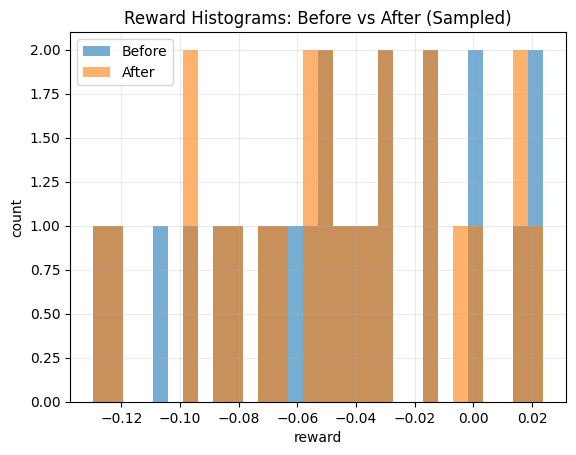

📝 Wrote summary table to: C:\Users\murth\Desktop\NLP+RL\code\class02\report.md


In [8]:
# Block 7 — Evaluation & Visualization

import os, io, numpy as np, pandas as pd, matplotlib.pyplot as plt

CACHE_PATH = os.path.join(DATA, "cache.csv")
REPORT_PATH = os.path.join(CLASS, "report.md")
assert os.path.exists(CACHE_PATH), "Run Block 3 and 5 first."

df = pd.read_csv(CACHE_PATH)

# Ensure needed columns exist for sampling
for col in ["logprob", "logprob_new"]:
    if col not in df.columns:
        raise RuntimeError(f"Missing '{col}' in cache. Run Block 5.")

# Softmax helper
def softmax(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / np.clip(e.sum(), 1e-12, None)

# Group by prompt, sample 1 completion before/after
before_rewards, after_rewards = [], []
for p, g in df.groupby("prompt"):
    # safety: at least 1 row
    if len(g) == 0: 
        continue
    # BEFORE: sample via logprob
    probs_b = softmax(g["logprob"].to_numpy())
    idx_b = np.random.choice(len(g), p=probs_b)
    rb = compute_reward(g.iloc[idx_b]["prompt"], g.iloc[idx_b]["completion"])
    before_rewards.append(rb)

    # AFTER: sample via logprob_new
    probs_a = softmax(g["logprob_new"].to_numpy())
    idx_a = np.random.choice(len(g), p=probs_a)
    ra = compute_reward(g.iloc[idx_a]["prompt"], g.iloc[idx_a]["completion"])
    after_rewards.append(ra)

before_rewards = np.array(before_rewards, dtype=float)
after_rewards  = np.array(after_rewards, dtype=float)

def stats(x):
    x = np.asarray(x, dtype=float)
    mean = float(np.mean(x)) if x.size else float("nan")
    std  = float(np.std(x, ddof=1)) if x.size > 1 else float("nan")
    # entropy from density histogram
    hist, _ = np.histogram(x, bins=40, density=True)
    p = hist[hist>0]
    entropy = float(-np.sum(p * np.log(p)))
    return mean, std, entropy

def kl_binned(p_samples, q_samples, bins=40, eps=1e-9):
    # KL(P||Q) on discretized rewards
    hp, edges = np.histogram(p_samples, bins=bins, density=True)
    hq, _     = np.histogram(q_samples, bins=edges, density=True)
    P = hp + eps; Q = hq + eps
    P /= P.sum(); Q /= Q.sum()
    return float(np.sum(P * np.log(P / Q)))

m_b, s_b, h_b = stats(before_rewards)
m_a, s_a, h_a = stats(after_rewards)
kl_ba = kl_binned(before_rewards, after_rewards)
kl_ab = kl_binned(after_rewards, before_rewards)

print("=== Evaluation (sampled once per prompt) ===")
print(f"Before: mean={m_b:.6f}  std={s_b:.6f}  entropy={h_b:.6f}")
print(f"After : mean={m_a:.6f}  std={s_a:.6f}  entropy={h_a:.6f}")
print(f"KL( before || after ) = {kl_ba:.6f}")
print(f"KL( after  || before) = {kl_ab:.6f}")

# Plot histograms
plt.figure()
plt.hist(before_rewards, bins=30, alpha=0.6, label="Before")
plt.hist(after_rewards,  bins=30, alpha=0.6, label="After")
plt.title("Reward Histograms: Before vs After (Sampled)")
plt.xlabel("reward"); plt.ylabel("count")
plt.legend(); plt.grid(True, alpha=0.25)
plt.show()

# Append/update report.md
table = f"""
| Phase  | Mean Reward | Std | Entropy | KL to Other |
|-------:|------------:|----:|--------:|------------:|
| Before | {m_b:.6f} | {s_b:.6f} | {h_b:.6f} | KL(B||A)={kl_ba:.6f} |
| After  | {m_a:.6f} | {s_a:.6f} | {h_a:.6f} | KL(A||B)={kl_ab:.6f} |
""".strip()

header = "# Session 02 — Reward-Model Evaluation & Offline RL Tuning (Report)\n\n## Results Summary\n\n"
if os.path.exists(REPORT_PATH):
    with open(REPORT_PATH, "a", encoding="utf-8") as f:
        f.write("\n\n" + header + table + "\n")
else:
    with open(REPORT_PATH, "w", encoding="utf-8") as f:
        f.write(header + table + "\n")

print(f"📝 Wrote summary table to: {REPORT_PATH}")


# Block 8 — Reflection (Student Writeup)
Add a Markdown cell below and answer briefly:
1. **Distribution Shift:** What changed in the reward distribution (mean/std/entropy)?  
2. **Variance & Collapse:** Did variance drop too much (hint: std/entropy)? Any signs of mode collapse?  
3. **Method Choice:** In your task, when would you prefer **DPO** over **PPO**, and why?  
4. **Safety Check:** Could your update have rewarded superficial patterns (reward hacking)? How would you detect/mitigate it?
